<a href="https://colab.research.google.com/github/arthireddy14/Machine_Learning/blob/main/variance_threshold_chisquare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Variance threshold

In [2]:
import pandas as pd
import numpy as np

In [ ]:
data=pd.DataFrame({
    'age':[18,20,30,22,45],
    'salary':[5000,7000,25000,15000,48000],
    'country_code':[1,1,1,1,1]
})
data

,age,salary,country_code
0,18,5000,1
1,20,7000,1
2,30,25000,1
3,22,15000,1
4,45,48000,1


In [ ]:
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.1)
selected_data=selector.fit_transform(data)

selected_features=data.columns[selector.get_support()]
print("Selected Features:",selected_features)

Selected Features: Index(['age', 'salary'], dtype='object')


Scenario: Hospital Disease Prediction System
You are building a machine learning model to predict whether a patient has a particular disease.
The dataset contains the following features:
Age
Blood Pressure
Cholesterol Level
Gender
Country Code
Hospital ID
Machine Version Used for Testing
After initial exploration, you notice:
Country Code is 100% “India” for all records
Machine Version is 99% “v2.1” and only 1% “v2.2”
Hospital ID is same for all patients
❓ Question:
Which feature selection technique would you apply first?
Which features would likely be removed?
Why is removing these features important before training?
What problem might occur if you keep them?

I would apply variance threshold method.Columns like country code,hospital id,machine version used for testing will be removed.These features does not effect or does not relate to the patient's disease prediction. Just the model takes more time by keeping these features.

**Correlation Coefficient**

In [ ]:
data=pd.DataFrame({
    'size_sqrt':[1000,2000,3000,4000,4500],
    'tiles_count':[100,200,300,400,480],
    'price':[1500000,3000000,4500000,6000000,6500000]
})
data

,size_sqrt,tiles_count,price
0,1000,100,1500000
1,2000,200,3000000
2,3000,300,4500000
3,4000,400,6000000
4,4500,480,6500000


In [ ]:
correlation_matrix=data.corr()
print(correlation_matrix)

             size_sqrt  tiles_count     price
size_sqrt     1.000000     0.997619  0.999118
tiles_count   0.997619     1.000000  0.993845
price         0.999118     0.993845  1.000000


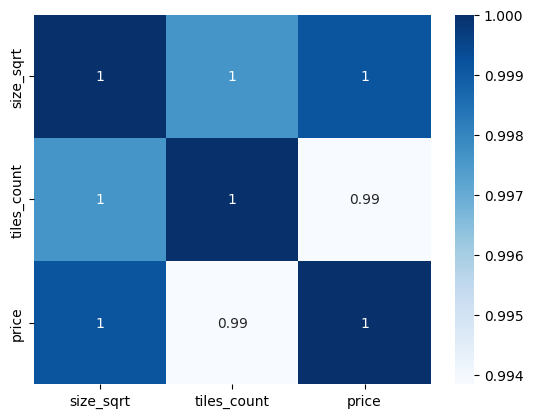

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(correlation_matrix,annot=True,cmap='Blues')
plt.show()

In [ ]:
# Removing highly correlated features (>0.9)
upper=correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
)
to_drop=[column for column in upper.columns if any(upper[column]>0.9)]
print("Highly correlated features to drop : ",to_drop)

Highly correlated features to drop :  ['tiles_count', 'price']


🏠 Scenario: Real Estate Price Prediction
You are developing a regression model to predict house prices.
Dataset contains:
House Size (sqft)
Number of Tiles
Total Construction Cost
Number of Bedrooms
Market Price
After calculating correlation matrix, you find:
House Size and Number of Tiles have 0.98 correlation
Construction Cost is highly correlated (0.95) with House Size
❓ Question:
Why is high correlation between features a problem?
Which feature(s) would you remove and why?
What issue can occur if highly correlated features are kept?
Which filter method is appropriate here?


In [ ]:
data=pd.DataFrame({
    'house_size(sqrt)':[200,250,300,350],
    'no_of_tiles':[80,100,150,300],
    'construction_cost':[1500000,1800000,2200000,3000000],
    'no_of_bedrooms':[2,3,4,6],
    'market_price':[1300000,2000000,2000000,3500000]
})
data

,house_size(sqrt),no_of_tiles,construction_cost,no_of_bedrooms,market_price
0,200,80,1500000,2,1300000
1,250,100,1800000,3,2000000
2,300,150,2200000,4,2000000
3,350,300,3000000,6,3500000


In [ ]:
x=data.drop(columns=['market_price'])
y=data['market_price']


In [ ]:
# Correlation matrix for predictors only

correlation_matrix=x.corr();
print(correlation_matrix)

                   house_size(sqrt)  no_of_tiles  construction_cost  \
house_size(sqrt)           1.000000     0.921612           0.973211   
no_of_tiles                0.921612     1.000000           0.986125   
construction_cost          0.973211     0.986125           1.000000   
no_of_bedrooms             0.982708     0.976323           0.998421   

                   no_of_bedrooms  
house_size(sqrt)         0.982708  
no_of_tiles              0.976323  
construction_cost        0.998421  
no_of_bedrooms           1.000000  


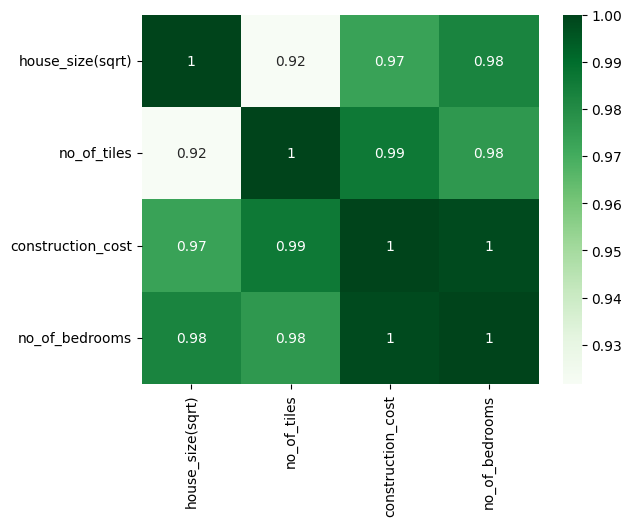

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(correlation_matrix,annot=True,cmap='Greens')
plt.show()

In [ ]:
upper=correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
)
to_drop=[column for column in upper.columns if any(upper[column]>0.9)]
print("Highly correlated features to drop : ",to_drop)

Highly correlated features to drop :  ['no_of_tiles', 'construction_cost', 'no_of_bedrooms']


In [ ]:
# Drop correlated features from predictors
x_filtered = x.drop(columns=to_drop)
print("\nFiltered Predictors:\n", x_filtered.head())



Filtered Predictors:
    house_size(sqrt)
0               200
1               250
2               300
3               350


y is the target variable not a predictor

Chi square

In [ ]:
x=pd.DataFrame({
    'gender':[1,0,0,1,1],
    'married':[0,1,1,0,1],
    'income':[10000,15000,20000,25000,27000]
})
y=[1,0,1,1,0]
x

,gender,married,income
0,1,0,10000
1,0,1,15000
2,0,1,20000
3,1,0,25000
4,1,1,27000


In [ ]:
# Chi square requires non-negative values
# Chi‑square → categorical features only.
# f_classif (ANOVA F‑test) → works for continuous + categorical

from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)

selector=SelectKBest(score_func=f_classif,k=2)
x_new=selector.fit_transform(x_scaled,y)
selected_features=x.columns[selector.get_support()]
print("Selected features : ",selected_features)


Selected features :  Index(['married', 'income'], dtype='object')


Scenario: Loan Approval Classification
You are building a classification model to predict whether a loan will be approved.
Dataset features:
Gender (Male/Female)
Marital Status (Yes/No)
Education Level (Graduate/Non-Graduate)
Applicant Income
Property Area (Urban/Rural)
Favorite Color
Loan Status (Approved/Rejected)
You want to identify which categorical features significantly influence loan approval.
❓ Question:
Which filter method is most appropriate here?
Which type of features can be tested using this method?
If “Favorite Color” has a very low chi-square score, what does it indicate?
Why is chi-square suitable only for classification problems?

In [3]:
data = pd.DataFrame({
    'gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    'married': [1, 1, 0, 1, 0, 1, 0, 0, 1, 1],
    'educated': [1, 0, 1, 1, 0, 1, 1, 0, 1, 0],
    'applicant_income': [50000, 30000, 40000, 80000, 25000, 60000, 32000, 45000, 28000, 70000],
    'property_area': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    'favorite_color': [0, 1, 2, 0, 1, 2, 0, 1, 2, 0],
    'loan_status': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1]
})

data

,gender,married,educated,applicant_income,property_area,favorite_color,loan_status
0,1,1,1,50000,1,0,1
1,0,1,0,30000,0,1,0
2,1,0,1,40000,1,2,1
3,1,1,1,80000,1,0,1
4,0,0,0,25000,0,1,0
5,1,1,1,60000,1,2,1
6,0,0,1,32000,0,0,0
7,1,0,0,45000,1,1,1
8,0,1,1,28000,0,2,0
9,1,1,0,70000,1,0,1


Apply Chi-Square test

Applicant income is continuous → chi-square is not suitable directly.

In [5]:
from sklearn.feature_selection import chi2,SelectKBest
x=data[['gender','married','educated','property_area','favorite_color']]
y=data['loan_status']
chi_scores=chi2(x,y)
chi_results=pd.DataFrame({
    'Feature':x.columns,
    'Chi2 Score': chi_scores[0],
    'p-value':chi_scores[1]
})
chi_results.sort_values(by='Chi2 Score',ascending=False)

,Feature,Chi2 Score,p-value
0,gender,4.000000,0.045500
3,property_area,4.000000,0.045500
1,married,0.111111,0.738883
2,educated,0.111111,0.738883
4,favorite_color,0.074074,0.785495


Which filter method is appropriate?

→ Chi-Square Test

Which features can be tested?

→ Only categorical features

gender

married

educated

property_area

favorite_color

Not applicant_income (continuous).

In [6]:
# If Favorite Color has very low chi-square score?
# It is independent of loan approval.
# It has no predictive power.
# We can safely remove it.

In [7]:
# Why chi-square only for classification?
# It compares frequency distributions.
# It requires categorical target variable.
# It cannot work with continuous targets.

From this sample:

✔ Education strongly influences loan approval
✔ Property area moderately influences
❌ Favorite color does not matter

So we remove irrelevant features before training model.